# Risk-Aware Trading Insights from Volatility and Volume Behavior
### Quantitative Research — Technology Equities Internship Assignment

**Date Range:** January 1, 2023 – January 1, 2026  
**Sector:** Technology Equities  
**Universe:** AAPL, NVDA, MSFT, TSLA, AMZN

---

## Objectives

This notebook investigates the price, volatility, and volume behavior of five large-cap technology stocks over a three-year window. Specifically, we aim to:

1. **Analyze** historical price behavior using returns, rolling volatility, and volume trends.
2. **Identify** 2–3 realistic volatility or momentum patterns across the selected names.
3. **Propose** a simple, rule-based trading strategy grounded in observed patterns.
4. **Backtest** that strategy against a passive buy-and-hold benchmark.
5. **Discuss** the limitations and risks of the approach.

All analysis is performed using `pandas`, `numpy`, `matplotlib`, and `yfinance`. No machine learning or advanced quantitative methods are used.


---
## 1. Data Collection

We download daily adjusted closing prices, volume, and OHLC data for all five tickers using `yfinance`. Adjusted close prices account for splits and dividends, making them appropriate for return calculations.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
TICKERS    = ["AAPL", "NVDA", "MSFT", "TSLA", "AMZN"]
START_DATE = "2023-01-01"
END_DATE   = "2026-01-01"
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
print("Downloaded columns:", list(raw.columns.get_level_values(0).unique()))
print("Date range       :", raw.index[0].date(), "→", raw.index[-1].date())
print("Trading days     :", len(raw))
print("\nFirst 3 rows of Adjusted Close:")
raw["Close"].head(3)


Downloaded columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Date range       : 2023-01-03 → 2025-12-31
Trading days     : 752

First 3 rows of Adjusted Close:


Ticker,AAPL,AMZN,MSFT,NVDA,TSLA
Date,,,,,
2023-01-03,122.982727,85.820000,232.948273,14.299910,108.099998
2023-01-04,124.251183,85.139999,222.758347,14.733453,113.639999
2023-01-05,122.933533,83.120003,216.156311,14.249964,110.339996


In [2]:
close  = raw["Close"].copy()   
volume = raw["Volume"].copy()   
high   = raw["High"].copy()    
low    = raw["Low"].copy()     
assert close.shape[1] == len(TICKERS), "Some tickers failed to download."
print("Close price shape:", close.shape)
print("Volume shape     :", volume.shape)
close.tail(3)


Close price shape: (752, 5)
Volume shape     : (752, 5)


Ticker,AAPL,AMZN,MSFT,NVDA,TSLA
Date,,,,,
2025-12-29,273.252350,232.070007,484.940430,188.209808,459.640015
2025-12-30,272.573547,232.529999,485.318726,187.529846,454.429993
2025-12-31,271.355835,230.820007,481.475861,186.489914,449.720001


## 2. Data Cleaning & Feature Engineering

Before starting the analysis, the data was cleaned to make sure the results were reliable and consistent.

* Missing values were filled using the previous available trading-day data wherever possible.
* Any remaining empty rows, mainly at the beginning of the dataset because of rolling calculations, were removed.

After cleaning, a few important features were created for each stock:

| Feature          | Simple Meaning                                                                   |
| ---------------- | -------------------------------------------------------------------------------- |
| `daily_return`   | Measures how much the stock price changed from one day to the next               |
| `rolling_vol_20` | Shows how volatile or unstable the stock price was over the past 20 trading days |
| `vol_avg_20`     | Average volatility over the last 20 days, used as a reference level              |
| `volume_avg_20`  | Average number of shares traded over the last 20 days                            |
| `drawdown`       | Measures how far the stock price has fallen from its recent highest point        |


In [24]:
close  = close.ffill()
volume = volume.ffill()
high   = high.ffill()
low    = low.ffill()
returns = np.log(close / close.shift(1))
rolling_vol = returns.rolling(20).std() * np.sqrt(252)
vol_avg = rolling_vol.rolling(20).mean()
vol_avg_volume = volume.rolling(20).mean()
def compute_drawdown(price_series):
    rolling_peak = price_series.cummax()
    dd = (price_series - rolling_peak) / rolling_peak
    return dd
drawdown = close.apply(compute_drawdown)
WARMUP = 40
close_clean  = close.iloc[WARMUP:]
returns_clean = returns.iloc[WARMUP:]
rolling_vol_clean = rolling_vol.iloc[WARMUP:]
vol_avg_clean = vol_avg.iloc[WARMUP:]
volume_clean  = volume.iloc[WARMUP:]
vol_avg_volume_clean = vol_avg_volume.iloc[WARMUP:]
drawdown_clean = drawdown.iloc[WARMUP:]

print(f"Clean dataset: {len(close_clean)} trading days ({close_clean.index[0].date()} → {close_clean.index[-1].date()})")
print("\nSample — daily returns (first 3 rows):")
returns_clean.head(3).round(4)


Clean dataset: 712 trading days (2023-03-02 → 2025-12-31)

Sample — daily returns (first 3 rows):


Ticker,AAPL,AMZN,MSFT,NVDA,TSLA
Date,,,,,
2023-03-02,0.0041,-0.0004,0.0195,0.0268,-0.0603
2023-03-03,0.0345,0.0296,0.0165,0.0244,0.0355
2023-03-06,0.0184,-0.0122,0.0062,-0.0142,-0.0203


In [4]:
summary = returns_clean.describe().T[["mean", "std", "min", "max"]]
summary.columns = ["Mean Daily Return", "Std Dev", "Min", "Max"]
summary = (summary * 100).round(3)   # express in %
summary["Annualised Vol (%)"] = (rolling_vol_clean.mean() * 100).round(2)
print("Daily Return Summary Statistics (%):\n")
print(summary.to_string())


Daily Return Summary Statistics (%):

        Mean Daily Return  Std Dev     Min     Max  Annualised Vol (%)
Ticker                                                                
AAPL                0.090    1.607  -9.701  14.262               23.33
AMZN                0.129    1.958  -9.408  11.312               29.99
MSFT                0.098    1.417  -6.380   9.652               21.66
NVDA                0.296    3.074 -18.595  21.809               46.17
TSLA                0.112    3.715 -16.755  20.449               56.54


---
## 3. Exploratory Data Analysis

Begin with three exploratory charts:

1. **Normalised price performance** — how $100 invested at the start of 2023 would have grown.
2. **Rolling 20-day annualised volatility** — to identify stress periods.
3. **Drawdown chart** — to understand peak-to-trough losses over time.

Each chart covers all five tickers so cross-sectional comparisons are easy.


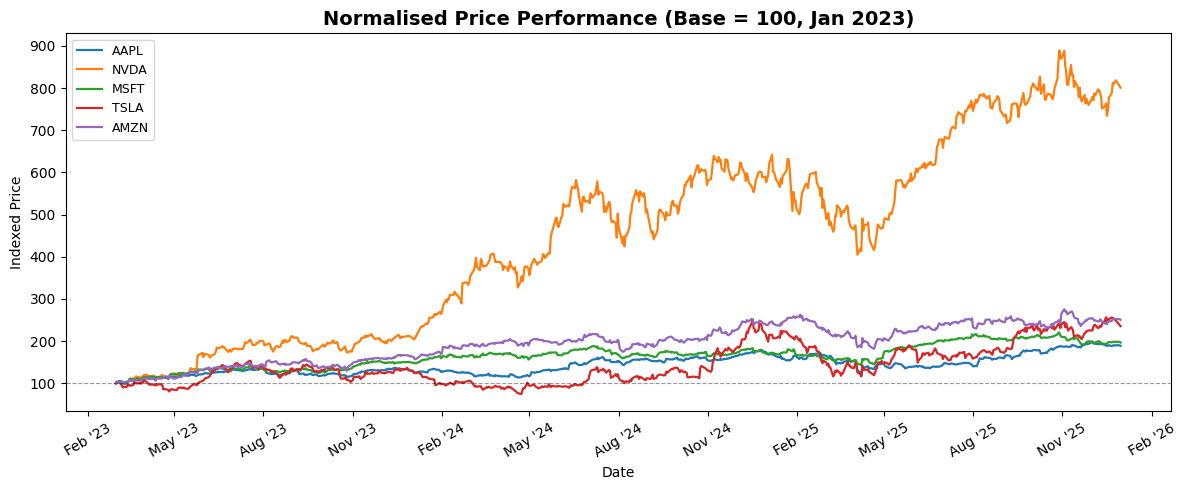

In [6]:
norm_price = (close_clean / close_clean.iloc[0]) * 100   # rebased to 100

fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.plot(norm_price.index, norm_price[ticker], label=ticker, linewidth=1.6)

ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Normalised Price Performance (Base = 100, Jan 2023)", fontsize=14, fontweight="bold")
ax.set_ylabel("Indexed Price")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


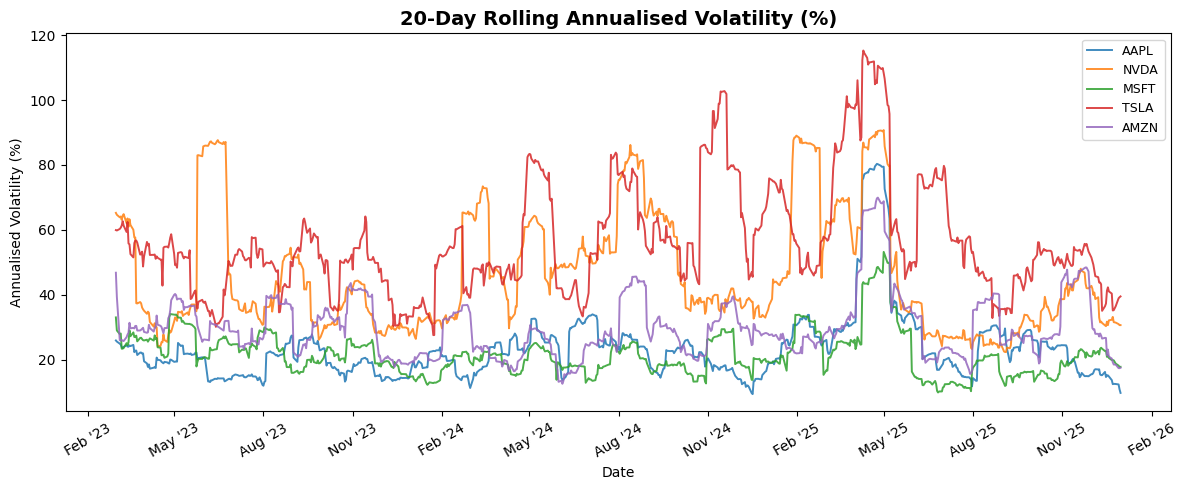

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.plot(rolling_vol_clean.index, rolling_vol_clean[ticker] * 100,
            label=ticker, linewidth=1.4, alpha=0.85)

ax.set_title("20-Day Rolling Annualised Volatility (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Annualised Volatility (%)")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


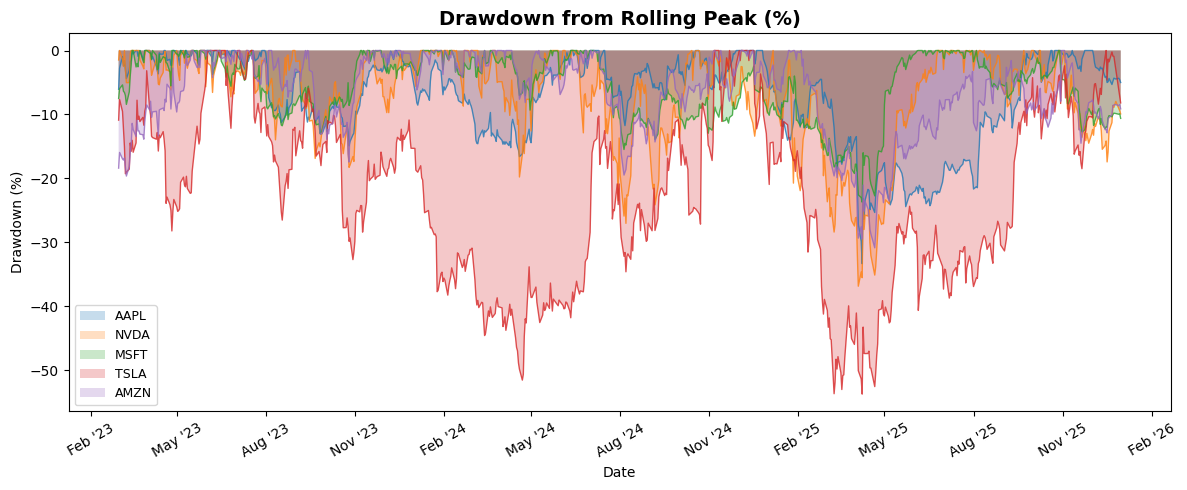

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.fill_between(drawdown_clean.index, drawdown_clean[ticker] * 100, 0,
                    alpha=0.25, label=ticker)
    ax.plot(drawdown_clean.index, drawdown_clean[ticker] * 100,
            linewidth=1.0, alpha=0.8)

ax.set_title("Drawdown from Rolling Peak (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


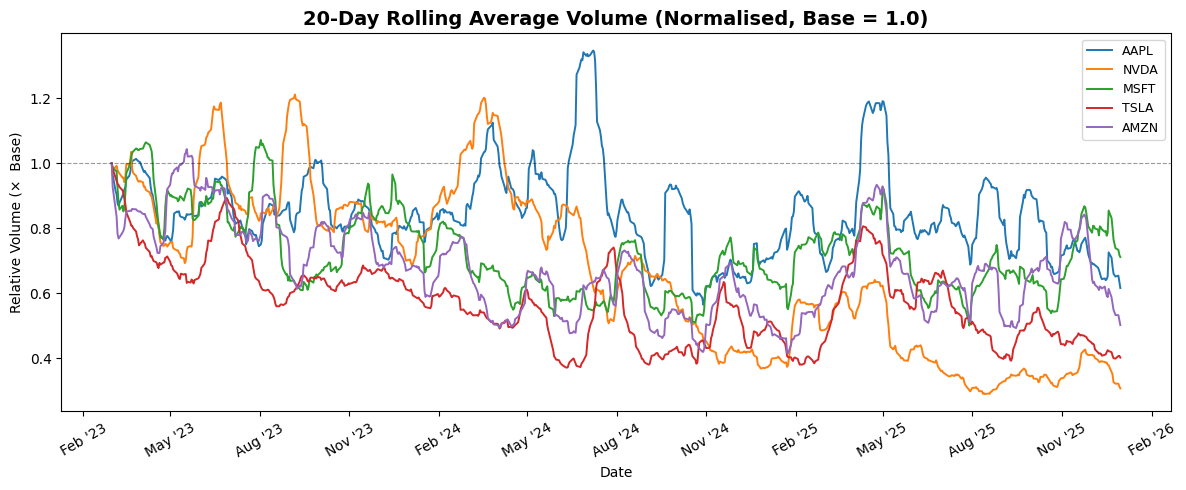

In [8]:
norm_vol = vol_avg_volume_clean / vol_avg_volume_clean.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.plot(norm_vol.index, norm_vol[ticker], label=ticker, linewidth=1.4)

ax.axhline(1, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("20-Day Rolling Average Volume (Normalised, Base = 1.0)", fontsize=14, fontweight="bold")
ax.set_ylabel("Relative Volume (×  Base)")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Pattern Identification

In this section, three common stock market behaviours were studied using the data.

### Pattern 1 — Strong Momentum in NVDA

NVDA showed a strong upward trend during 2023–2024, mainly because of growing demand for AI and GPUs. The idea tested here was simple: if NVDA had a good week, was it likely to continue performing well in the next few days? The data was checked to see whether positive movements were often followed by more positive movements.

### Pattern 2 — Recovery After Big Drops in TSLA

TSLA is a highly volatile stock, meaning its price moves sharply very often. This section looked at what happened after very large one-day falls (more than 5%). The goal was to see whether the stock usually bounced back and gave positive returns in the next few days after a heavy drop.

### Pattern 3 — High Volume During Volatile Periods

For all the selected stocks, periods of strong price movement were compared with trading activity. In many cases, when prices became more volatile, trading volume also increased sharply. This helps in understanding how markets behave during stressful or uncertain periods.


NVDA — Average 5-day forward return:
  After a positive 5-day period : 1.73%
  After a negative 5-day period : 1.64%

Two-sample t-test: t = 0.179, p = 0.858
  → Not significant at 5% level. Treat as descriptive only.


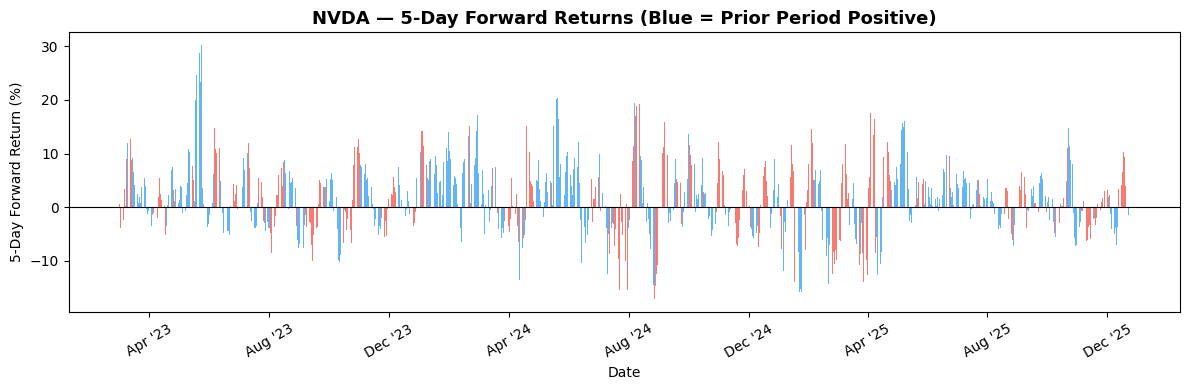

In [9]:
# ── Pattern 1: NVDA Momentum Persistence
from scipy import stats

nvda_5d_ret = close_clean["NVDA"].pct_change(5)
nvda_signal = (nvda_5d_ret.shift(1) > 0)
nvda_fwd5   = nvda_5d_ret.shift(-5)

pos_fwd = nvda_fwd5[nvda_signal].dropna()
neg_fwd = nvda_fwd5[~nvda_signal].dropna()

print("NVDA — Average 5-day forward return:")
print(f"  After a positive 5-day period : {pos_fwd.mean()*100:.2f}%")
print(f"  After a negative 5-day period : {neg_fwd.mean()*100:.2f}%")

# Statistical significance (two-sample t-test, unequal variances)
t_stat, p_val = stats.ttest_ind(pos_fwd, neg_fwd, equal_var=False)
print(f"\nTwo-sample t-test: t = {t_stat:.3f}, p = {p_val:.3f}")
if p_val > 0.05:
    print("  → Not significant at 5% level. Treat as descriptive only.")
else:
    print("  → Significant at 5% level.")

fig, ax = plt.subplots(figsize=(12, 4))
colors = nvda_signal.map({True: "#2196F3", False: "#F44336"})
ax.bar(nvda_fwd5.index, nvda_fwd5 * 100, color=colors, width=1, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("NVDA — 5-Day Forward Returns (Blue = Prior Period Positive)", fontsize=13, fontweight="bold")
ax.set_ylabel("5-Day Forward Return (%)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


TSLA — Days with daily return < -5%: 47
TSLA — Mean forward returns after a >5% single-day drop:
  1-day forward : mean = +1.42%   |   win rate = 66%
  3-day forward : mean = +1.47%   |   win rate = 49%
  5-day forward : mean = +2.64%   |   win rate = 55%

Binomial test (3-day win rate vs 50%): p = 0.615
  → Not significant (n=47 trades). Pattern is suggestive but not conclusive.


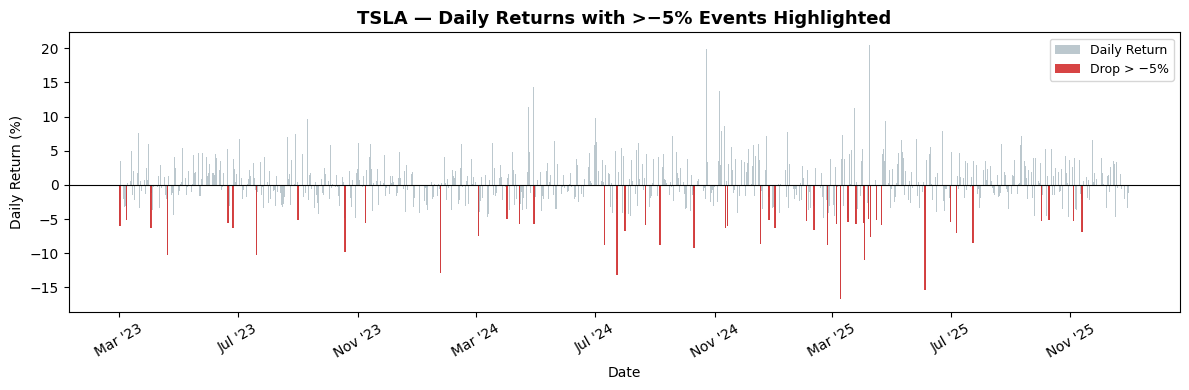

In [12]:
THRESHOLD = -0.05
tsla_ret = returns_clean["TSLA"]
big_drop_days = tsla_ret[tsla_ret < THRESHOLD].index
print(f"TSLA — Days with daily return < {THRESHOLD*100:.0f}%: {len(big_drop_days)}")

fwd_returns = {}
for horizon in [1, 3, 5]:
    fwd = []
    for day in big_drop_days:
        try:
            loc     = close_clean.index.get_loc(day)
            fwd_ret = (close_clean["TSLA"].iloc[loc + horizon] /
                       close_clean["TSLA"].iloc[loc] - 1)
            fwd.append(fwd_ret)
        except IndexError:
            pass
    fwd_returns[horizon] = fwd

print("TSLA — Mean forward returns after a >5% single-day drop:")
for h, vals in fwd_returns.items():
    mean_ret = np.mean(vals) * 100
    win_rate = np.mean([v > 0 for v in vals]) * 100
    print(f"  {h}-day forward : mean = {mean_ret:+.2f}%   |   win rate = {win_rate:.0f}%")

# Binomial test on 3-day win rate: H0 = win rate is 50% (no edge)
from scipy.stats import binomtest
vals_3d = fwd_returns[3]
n_obs   = len(vals_3d)
n_wins  = sum(v > 0 for v in vals_3d)
btest   = binomtest(n_wins, n_obs, p=0.5, alternative='greater')
print(f"\nBinomial test (3-day win rate vs 50%): p = {btest.pvalue:.3f}")
if btest.pvalue > 0.05:
    print(f"  → Not significant (n={n_obs} trades). Pattern is suggestive but not conclusive.")
else:
    print(f"  → Significant at 5% level (n={n_obs} trades).")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tsla_ret.index, tsla_ret * 100, width=1, color="#90A4AE", alpha=0.6, label="Daily Return")
drop_vals = tsla_ret[big_drop_days]
ax.bar(drop_vals.index, drop_vals * 100, width=1.5, color="#D32F2F", alpha=0.9, label="Drop > −5%")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("TSLA — Daily Returns with >−5% Events Highlighted", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily Return (%)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


TSLA — Pearson correlation between rolling vol and daily volume: 0.127


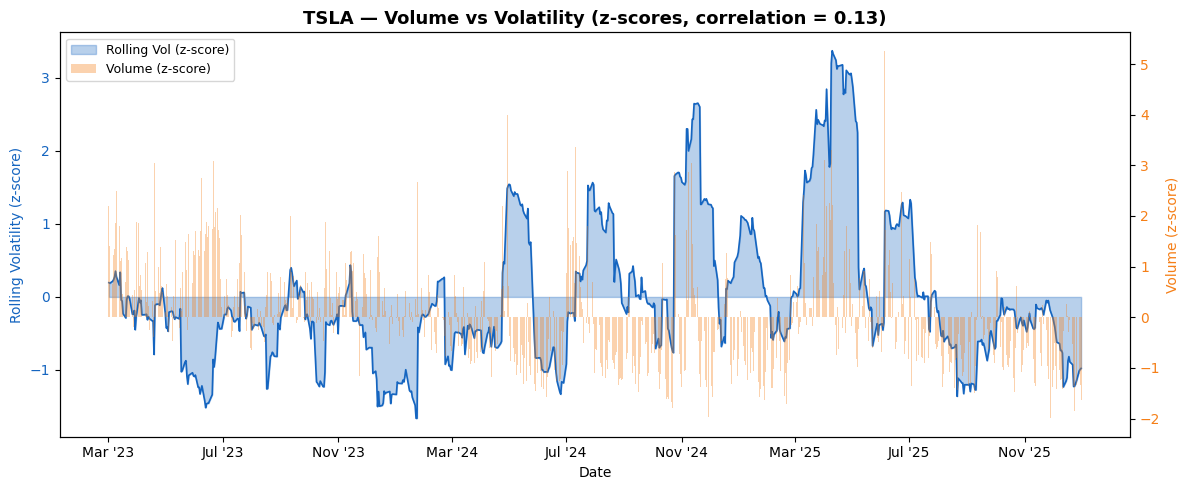

In [13]:
def zscore(s):
    return (s - s.mean()) / s.std()
tsla_vol_z   = zscore(rolling_vol_clean["TSLA"])
tsla_volm_z  = zscore(volume_clean["TSLA"])
corr = tsla_vol_z.corr(tsla_volm_z)
print(f"TSLA — Pearson correlation between rolling vol and daily volume: {corr:.3f}")
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.fill_between(tsla_vol_z.index, tsla_vol_z, alpha=0.3, color="#1565C0", label="Rolling Vol (z-score)")
ax1.plot(tsla_vol_z.index, tsla_vol_z, color="#1565C0", linewidth=1.2)
ax1.set_ylabel("Rolling Volatility (z-score)", color="#1565C0")
ax1.tick_params(axis="y", labelcolor="#1565C0")

ax2 = ax1.twinx()
ax2.bar(tsla_volm_z.index, tsla_volm_z, width=1, color="#F57F17", alpha=0.35, label="Volume (z-score)")
ax2.set_ylabel("Volume (z-score)", color="#F57F17")
ax2.tick_params(axis="y", labelcolor="#F57F17")

ax1.set_title(f"TSLA — Volume vs Volatility (z-scores, correlation = {corr:.2f})", fontsize=13, fontweight="bold")
ax1.set_xlabel("Date")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


In [14]:
print("Pearson Correlation: Rolling Volatility vs Daily Volume\n")
for ticker in TICKERS:
    v_z  = zscore(rolling_vol_clean[ticker])
    vm_z = zscore(volume_clean[ticker])
    c    = v_z.corr(vm_z)
    print(f"  {ticker}: {c:.3f}")


Pearson Correlation: Rolling Volatility vs Daily Volume

  AAPL: 0.175
  NVDA: 0.240
  MSFT: 0.227
  TSLA: 0.127
  AMZN: 0.210


## 5. Trading Strategy Definition

### Strategy: Buying the Dip During High Volatility

### Why this strategy was chosen

From the earlier analysis, TSLA and some other stocks showed a tendency to recover after sharp one-day drops. Based on that idea, a simple trading strategy was created to test whether buying after a big fall could give short-term profits.

The expectation was that this strategy would work better for stocks that usually bounce back after falling, like TSLA or AAPL. At the same time, NVDA was included because it behaves more like a momentum stock, where trends continue instead of reversing quickly. If the strategy performs poorly on NVDA but better on the others, it supports the idea that mean reversion is actually driving the results.

### Conditions to Buy

A trade is taken only if both of these conditions happen on the same day:

1. The stock falls more than 5% in a single day.
2. The stock is already in a high-volatility period compared to its recent average.

The idea is to capture situations where the market is stressed and prices may recover after an overreaction.

### How the Trade is Executed

The signal is identified after the market closes on a given day.
The actual trade is entered on the next trading day to avoid using future information unfairly in the backtest.

### Exit Rule

* Once a trade is entered, the stock is held for 3 trading days.
* After 3 days, the position is closed automatically.
* No stop-loss or profit target was added to keep the strategy simple.

### Stocks Used

The strategy was tested separately on all 5 selected stocks.

### Position Size

For simplicity, each trade used the full amount of capital assigned to that stock. Results were first tested individually and then combined.

> This is only a simulated backtest using historical data. Real trading would also include factors like slippage, execution delays, and transaction costs.


In [15]:
RETURN_THRESHOLD = -0.05    
HOLD_DAYS        = 3        

def generate_signals(ret_series, vol_series, vol_avg_series):
    """
    Returns a boolean Series: True on days that satisfy both entry conditions.
    ret_series    : daily log returns
    vol_series    : 20-day rolling volatility
    vol_avg_series: 20-day rolling average of volatility
    """
    cond_return = ret_series < RETURN_THRESHOLD          
    cond_vol    = vol_series > vol_avg_series            
    return cond_return & cond_vol

# Generate signals for every ticker
signals = pd.DataFrame(index=returns_clean.index, columns=TICKERS, dtype=bool)
for ticker in TICKERS:
    signals[ticker] = generate_signals(
        returns_clean[ticker],
        rolling_vol_clean[ticker],
        vol_avg_clean[ticker]
    )

# Count signals per ticker
print("Number of entry signals per ticker:")
print(signals.sum().to_string())
print(f"\nTotal signals across universe: {signals.sum().sum()}")


Number of entry signals per ticker:
AAPL     3
NVDA    16
MSFT     2
TSLA    34
AMZN     6

Total signals across universe: 61


---
## 6. Backtesting

We simulate the strategy on each ticker independently using a simplified event-driven backtest:

- On each signal day `t`, we "buy" at the close of day `t`.
- We "sell" at the close of day `t + 3`.
- We record the 3-day return for that trade.
- Trades do **not** overlap: if a new signal fires while a trade is open, it is skipped.

Then compute four performance metrics:

| Metric | Description |
|---|---|
| **Cumulative Return** | Total % gain/loss from all trades |
| **Win Rate** | % of trades that were profitable |
| **Max Drawdown** | Largest peak-to-trough loss in the equity curve |
| **Benchmark** | Buy-and-hold return over the same period |


In [16]:
def backtest_ticker(price_series, signal_series, hold_days=3):
    """
    Event-driven backtest.
    Entry  : close of day AFTER signal fires (t+1) — no look-ahead bias.
    Exit   : close of day t+1+hold_days.
    Equity : marked-to-market daily during the hold.
    No overlapping trades.
    """
    prices  = price_series.values
    dates   = price_series.index
    signals = signal_series.values
    n       = len(prices)

    trades = []
    equity = np.ones(n)
    cash   = 1.0

    in_trade    = False
    entry_price = None
    entry_date  = None
    exit_idx    = None

    for i in range(n):

        # ── 1. Close trade on exit day ─────────────────────────────────────
        if in_trade and i == exit_idx:
            trade_ret    = prices[i] / entry_price - 1
            cash        *= (1 + trade_ret)
            trades.append({
                "entry_date": entry_date,
                "exit_date":  dates[i],
                "return_pct": trade_ret * 100
            })
            in_trade = False

        # ── 2. Mark-to-market (or hold cash) ──────────────────────────────
        if in_trade:
            equity[i] = cash * (prices[i] / entry_price)
        else:
            equity[i] = cash

        # ── 3. Open trade: signal on day i → enter at day i+1 close ───────
        if (
            not in_trade
            and signals[i]
            and i + 1 + hold_days < n   # enough room to hold and exit
        ):
            entry_price = prices[i + 1]   # next-day close
            entry_date  = dates[i + 1]
            exit_idx    = i + 1 + hold_days
            in_trade    = True

    return pd.DataFrame(trades), pd.Series(equity, index=dates)


In [17]:
# ── Rebuild backtest results safely ───────────────────────────────────────────

all_trades = {}
equity_curves = {}

for ticker in TICKERS:

    try:

        trades_df, eq_curve = backtest_ticker(
            close_clean[ticker],
            signals[ticker],
            hold_days=HOLD_DAYS
        )

        all_trades[ticker] = trades_df
        equity_curves[ticker] = eq_curve

        print(f"✓ Backtest completed for {ticker}")

    except Exception as e:

        print(f"✗ Error processing {ticker}: {e}")

# ── Verify dictionary contents ────────────────────────────────────────────────

print("\nAvailable equity curves:")
print(list(equity_curves.keys()))

✓ Backtest completed for AAPL
✓ Backtest completed for NVDA
✓ Backtest completed for MSFT
✓ Backtest completed for TSLA
✓ Backtest completed for AMZN

Available equity curves:
['AAPL', 'NVDA', 'MSFT', 'TSLA', 'AMZN']


In [ ]:
def max_drawdown(equity_curve):
    ec = pd.Series(equity_curve).dropna()
    if ec.empty:
        return 0.0
    return ((ec - ec.cummax()) / ec.cummax()).min() * 100

def sharpe_sortino(equity_curve, rf_annual=0.0):
    """Annualised Sharpe and Sortino from daily equity curve."""
    daily_ret = pd.Series(equity_curve).pct_change().dropna()
    excess    = daily_ret - rf_annual / 252
    if excess.std() == 0:
        return np.nan, np.nan
    sharpe  = (excess.mean() / excess.std()) * np.sqrt(252)
    down    = excess[excess < 0]
    sortino = (excess.mean() / down.std()) * np.sqrt(252) if len(down) > 1 else np.nan
    return round(sharpe, 2), round(sortino, 2)

def time_in_market(signal_series, hold_days):
    """Fraction of days with an open position (accounts for t+1 entry)."""
    n        = len(signal_series)
    in_mkt   = np.zeros(n, dtype=bool)
    in_trade = False
    exit_i   = None
    for i in range(n):
        if in_trade and i == exit_i:
            in_trade = False
        if in_trade:
            in_mkt[i] = True
        if not in_trade and signal_series.iloc[i] and i + 1 + hold_days < n:
            in_trade = True
            exit_i   = i + 1 + hold_days
    return round(in_mkt.mean() * 100, 1)

# ── Build Results Table ───────────────────────────────────────────────────────

results = []

for ticker in TICKERS:

    trades_df = all_trades.get(ticker, pd.DataFrame())
    eq        = pd.Series(equity_curves.get(ticker, pd.Series(dtype=float))).dropna()
    n_trades  = len(trades_df)

    bnh_return = (close_clean[ticker].iloc[-1] / close_clean[ticker].iloc[0] - 1) * 100

    if n_trades == 0 or eq.empty:
        results.append({"Ticker": ticker, "# Trades": 0,
                        "Win Rate (%)": 0.0, "Cum Return (%)": 0.0,
                        "Sharpe": np.nan, "Sortino": np.nan,
                        "Max DD (%)": 0.0, "Time in Mkt (%)": 0.0,
                        "Buy & Hold (%)": round(bnh_return, 2)})
        continue

    win_rate   = (trades_df["return_pct"] > 0).mean() * 100
    cum_ret    = (eq.iloc[-1] - 1) * 100
    mdd        = max_drawdown(eq)
    sh, so     = sharpe_sortino(eq)
    tim        = time_in_market(signals[ticker], HOLD_DAYS)

    results.append({
        "Ticker":           ticker,
        "# Trades":         n_trades,
        "Win Rate (%)":     round(win_rate, 2),
        "Cum Return (%)":   round(cum_ret, 2),
        "Sharpe":           sh,
        "Sortino":          so,
        "Max DD (%)":       round(mdd, 2),
        "Time in Mkt (%)":  tim,
        "Buy & Hold (%)":   round(bnh_return, 2)
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("Cum Return (%)", ascending=False)
      .set_index("Ticker")
)

print("── Strategy Performance Summary ──────────────────────────────────────")
display(results_df)
print("\nNote: Sharpe/Sortino are computed on the full daily equity curve.")
print("Low time-in-market means the strategy is largely in cash — risk-adjusted")
print("metrics should be interpreted alongside time-in-market exposure.")


── Strategy Performance Summary ──────────────────────────────────────


,# Trades,Win Rate (%),Cum Return (%),Sharpe,Sortino,Max DD (%),Time in Mkt (%),Buy & Hold (%)
Ticker,,,,,,,,
AMZN,6,66.67,24.09,0.85,0.53,-5.70,2.5,150.54
TSLA,28,50.00,11.53,0.28,0.17,-27.25,11.8,135.58
AAPL,1,100.00,5.56,0.24,0.16,-8.47,0.4,88.84
MSFT,2,50.00,1.95,0.46,0.12,-1.00,0.8,96.70
NVDA,14,35.71,-35.59,-1.11,-0.43,-39.56,5.9,700.75



Note: Sharpe/Sortino are computed on the full daily equity curve.
Low time-in-market means the strategy is largely in cash — risk-adjusted
metrics should be interpreted alongside time-in-market exposure.


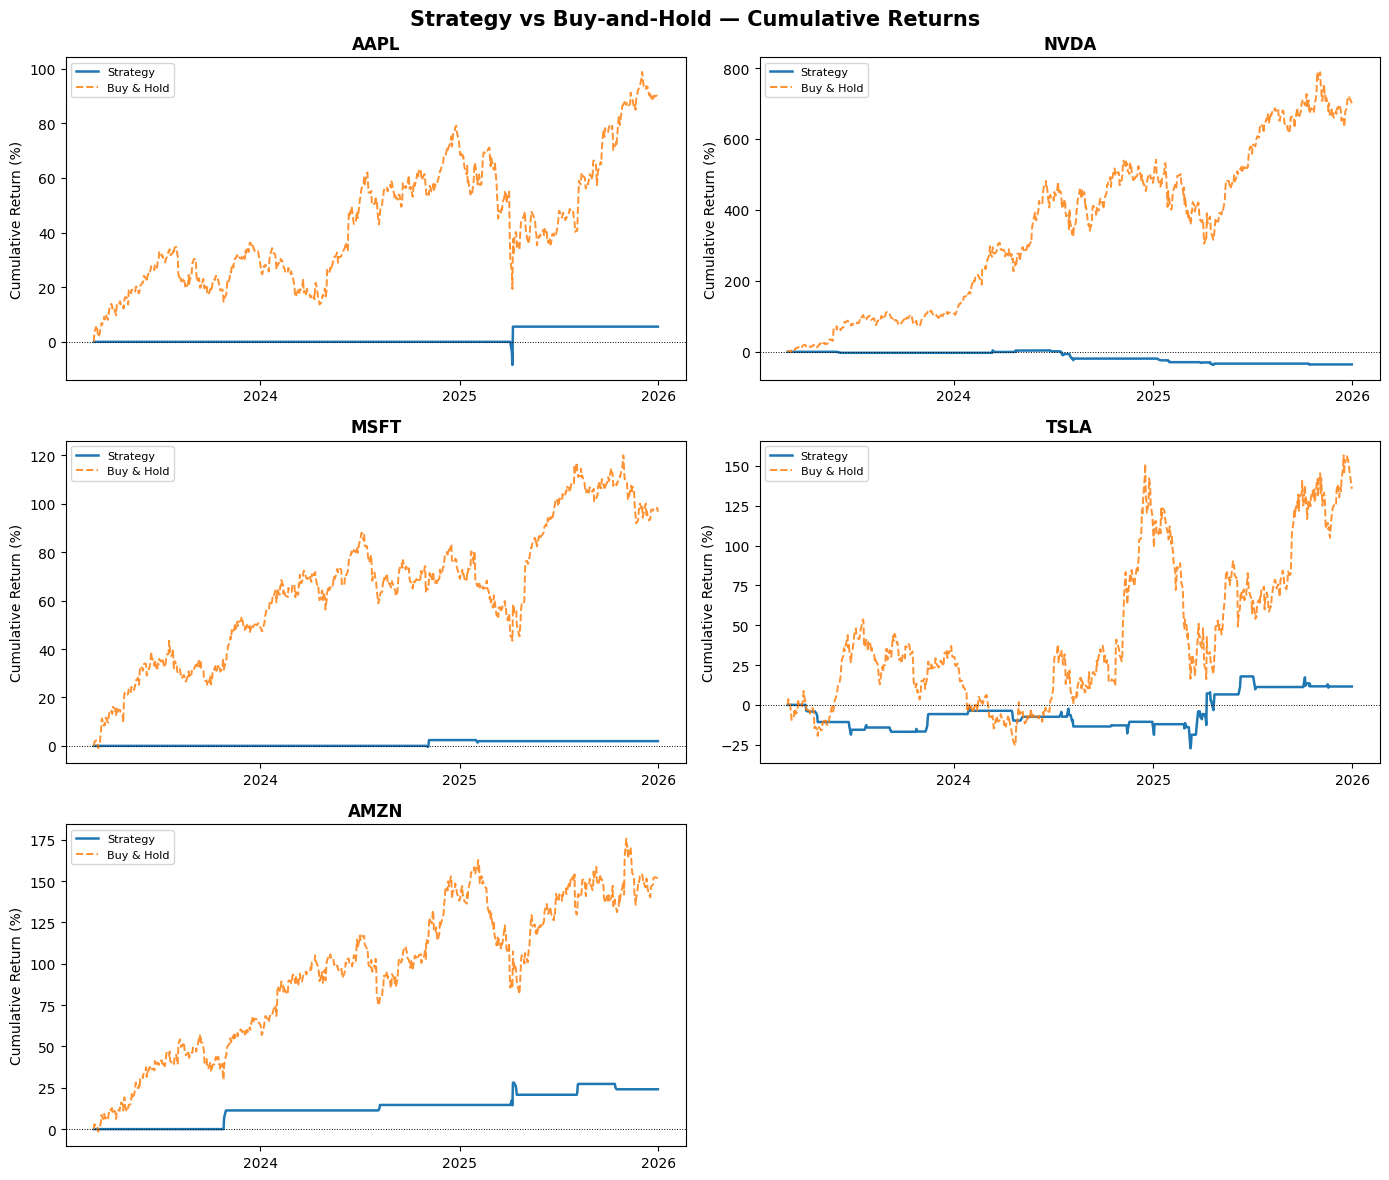

In [ ]:


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes = axes.flatten()

for idx, ticker in enumerate(TICKERS):

    ax = axes[idx]
    if ticker not in equity_curves:

        ax.set_visible(False)
        continue
    eq = equity_curves[ticker]

    strategy_returns = (eq - 1) * 100

    ax.plot(
        eq.index,
        strategy_returns,
        linewidth=1.8,
        label="Strategy"
    )
    bnh = (
        close_clean[ticker] /
        close_clean[ticker].iloc[0] - 1
    ) * 100

    ax.plot(
        bnh.index,
        bnh,
        linestyle="--",
        linewidth=1.4,
        alpha=0.85,
        label="Buy & Hold"
    )
    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")

    ax.set_title(
        ticker,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel("Cumulative Return (%)")

    ax.legend(fontsize=8)

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    ax.xaxis.set_major_locator(
        mdates.YearLocator()
    )
if len(TICKERS) < len(axes):

    for j in range(len(TICKERS), len(axes)):
        axes[j].set_visible(False)

fig.suptitle(
    "Strategy vs Buy-and-Hold — Cumulative Returns",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

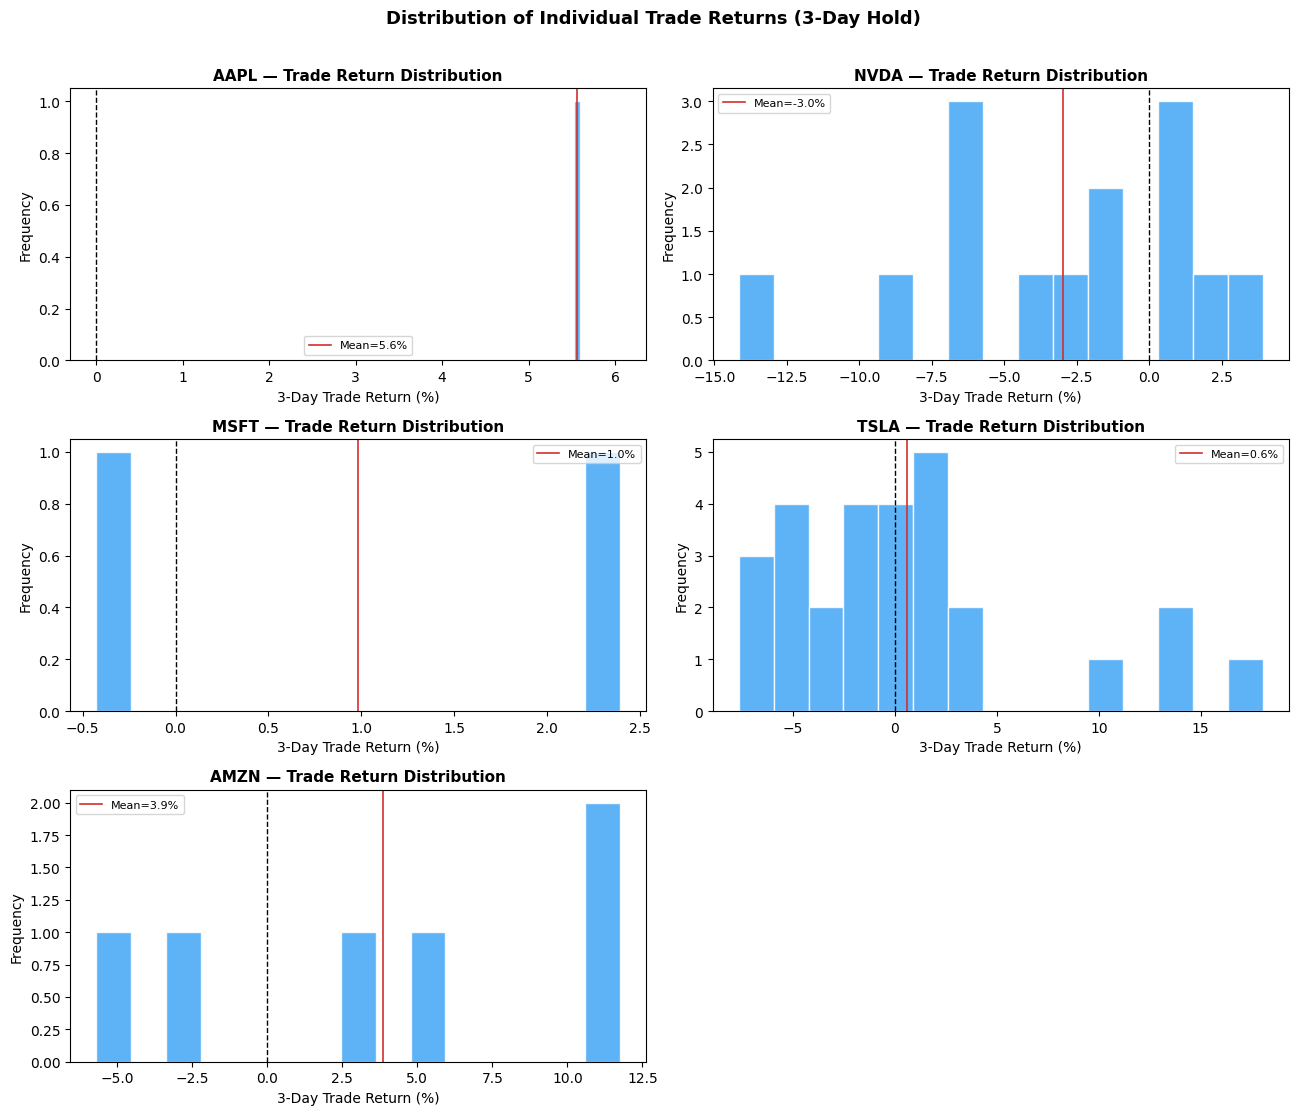

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
axes = axes.flatten()

for idx, ticker in enumerate(TICKERS):
    ax = axes[idx]
    tr = all_trades[ticker]["return_pct"] if len(all_trades[ticker]) > 0 else pd.Series(dtype=float)

    if len(tr) == 0:
        ax.text(0.5, 0.5, "No trades", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.hist(tr, bins=15, color="#42A5F5", edgecolor="white", alpha=0.85)
        ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
        ax.axvline(tr.mean(), color="#D32F2F", linewidth=1.2, linestyle="-", label=f"Mean={tr.mean():.1f}%")
        ax.legend(fontsize=8)

    ax.set_title(f"{ticker} — Trade Return Distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel("3-Day Trade Return (%)")
    ax.set_ylabel("Frequency")

axes[-1].set_visible(False)
plt.suptitle("Distribution of Individual Trade Returns (3-Day Hold)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 7. Risk Analysis

No strategy analysis is complete without a sober assessment of the risks involved. We examine:

1. **Max drawdown** — already computed per ticker.
2. **Win rate vs average trade return** — to understand the risk-reward profile.
3. **Transaction cost sensitivity** — how much does the strategy degrade if we apply realistic round-trip costs?
4. **Strategy limitations** — qualitative discussion.


In [ ]:
risk_rows = []
for ticker in TICKERS:
    tr = all_trades[ticker]["return_pct"] if len(all_trades[ticker]) > 0 else pd.Series(dtype=float)
    if len(tr) == 0:
        continue
    risk_rows.append({
        "Ticker"            : ticker,
        "Avg Win (%)"       : round(tr[tr > 0].mean(), 2) if (tr > 0).any() else 0,
        "Avg Loss (%)"      : round(tr[tr <= 0].mean(), 2) if (tr <= 0).any() else 0,
        "Win / Loss Ratio"  : round(abs(tr[tr > 0].mean() / tr[tr <= 0].mean()), 2) if (tr <= 0).any() and (tr > 0).any() else np.nan,
        "Max Single Loss (%)": round(tr.min(), 2),
        "Max DD (%)": round(max_drawdown(equity_curves[ticker]), 2)
    })

risk_df = pd.DataFrame(risk_rows).set_index("Ticker")
print("── Risk Summary Table")
print(risk_df.to_string())


── Risk Summary Table
        Avg Win (%)  Avg Loss (%)  Win / Loss Ratio  Max Single Loss (%)  Max DD (%)
Ticker                                                                              
AAPL           5.56          0.00               NaN                 5.56       -8.47
NVDA           1.87         -5.66              0.33               -14.16      -39.56
MSFT           2.39         -0.43              5.61                -0.43       -1.00
TSLA           5.19         -4.03              1.29                -7.66      -27.25
AMZN           7.86         -4.12              1.91                -5.70       -5.70


In [ ]:

cost_scenarios = [0.0, 0.001, 0.0025, 0.005]   

print("Net Cumulative Return (%) after Round-Trip Transaction Costs:\n")
header = f"{'Ticker':<8}" + "".join([f"  {int(c*10000)}bps" for c in cost_scenarios])
print(header)
print("─" * len(header))

for ticker in TICKERS:
    tr = all_trades[ticker]["return_pct"] / 100    
    n  = len(tr)
    row = f"{ticker:<8}"
    for cost in cost_scenarios:
        net_trades = tr - cost           
        cum_ret    = ((1 + net_trades).prod() - 1) * 100
        row       += f"  {cum_ret:+.1f}%  "
    print(row)


Net Cumulative Return (%) after Round-Trip Transaction Costs:

Ticker    0bps  10bps  25bps  50bps
───────────────────────────────────
AAPL      +5.6%    +5.5%    +5.3%    +5.1%  
NVDA      -35.6%    -36.5%    -37.9%    -40.1%  
MSFT      +2.0%    +1.8%    +1.4%    +0.9%  
TSLA      +11.5%    +8.5%    +4.0%    -3.0%  
AMZN      +24.1%    +23.4%    +22.3%    +20.5%  


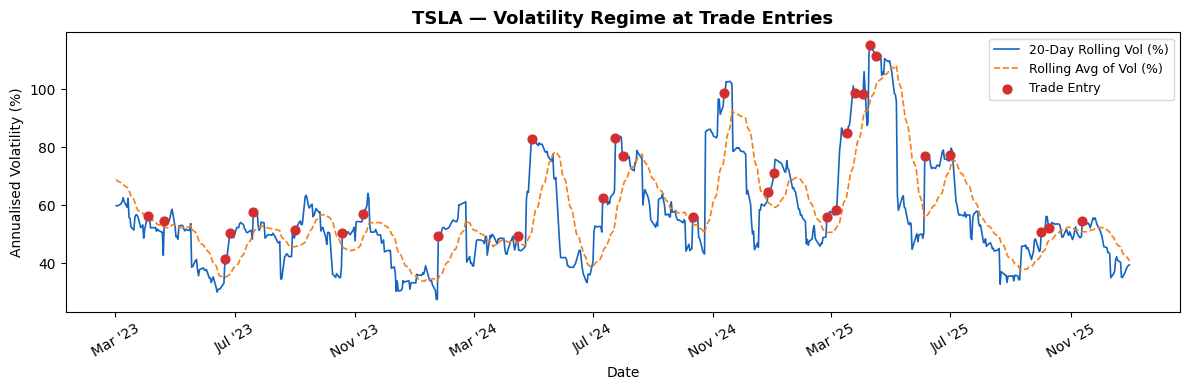

In [ ]:
ticker  = "TSLA"
t_dates = all_trades[ticker]["entry_date"] if len(all_trades[ticker]) > 0 else []

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_vol_clean.index, rolling_vol_clean[ticker] * 100,
        color="#1565C0", linewidth=1.2, label="20-Day Rolling Vol (%)")
ax.plot(vol_avg_clean.index, vol_avg_clean[ticker] * 100,
        color="#F57F17", linewidth=1.2, linestyle="--", label="Rolling Avg of Vol (%)")
if len(t_dates) > 0:
    trade_vol = rolling_vol_clean[ticker].reindex(t_dates) * 100
    ax.scatter(t_dates, trade_vol, color="#D32F2F", zorder=5, s=40, label="Trade Entry")

ax.set_title(f"{ticker} — Volatility Regime at Trade Entries", fontsize=13, fontweight="bold")
ax.set_ylabel("Annualised Volatility (%)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 8 . Conclusion 



The main goal of this project was to check whether simple market behaviours could actually be observed in real stock data and whether those patterns could be turned into a profitable trading strategy. Some patterns did appear clearly in the data, but the results also showed how difficult it is to build a reliable trading system from them.

NVDA showed strong momentum behaviour during 2023–2025. After strong upward moves, the stock often continued rising further, which matched the momentum pattern identified earlier. This became important in the strategy results because the dip-buying approach performed worst on NVDA. The strategy produced a cumulative return of **−35.59%** with only a **35.71% win rate**, while simple buy-and-hold on NVDA returned **700.75%** over the same period. This supports the original “negative control” idea: a mean-reversion strategy performs poorly on a stock driven mainly by momentum trends.

TSLA showed more evidence of mean reversion. After large one-day drops, the stock sometimes recovered over the following few trading sessions. The strategy results reflected this partially. TSLA generated **28 trades**, the highest among all stocks tested, with a **50% win rate** and an overall return of **11.53%**. However, buy-and-hold still performed much better at **135.58%**, meaning the short-term recovery effect was not strong enough to consistently beat long-term ownership.

AMZN produced the strongest strategy performance among all five stocks. The strategy returned **24.09%** with a relatively high **66.67% win rate** and a Sharpe ratio of **0.85**. Even then, it still significantly underperformed buy-and-hold, which returned **150.54%**. AAPL and MSFT also showed limited usefulness for the strategy because there were very few trading signals. AAPL had only **1 trade**, while MSFT had only **2 trades**, making it impossible to draw strong conclusions from those results.

Another clear observation was the relationship between trading volume and volatility. During stressful market periods, price swings and trading activity increased together across almost all stocks. This was not a surprising discovery, but it confirmed that the data behaved realistically and helped support the volatility filter used in the strategy.

One major weakness of the project was the small sample size. Most stocks generated very few trades over three years, which makes the results statistically weak. A small number of successful or failed trades can heavily distort overall performance. The strategy also stayed out of the market most of the time, with time-in-market ranging from only **0.4% to 11.8%**, limiting total return potential.

The project also highlighted an important lesson in quantitative finance: a strategy that sounds reasonable in theory can struggle badly in real conditions once factors like transaction costs, slippage, market trends, and limited data are considered. Backtesting alone is not enough to prove that a strategy has a genuine edge.

Overall, this project was valuable not because it discovered a perfect trading system, but because it demonstrated the process of testing ideas critically, measuring risk realistically, and understanding the gap between theoretical strategies and actual market behaviour. Future improvements should focus on using a larger stock universe, performing proper out-of-sample testing, and adding stronger risk-management rules before making stronger claims about profitability.


---
## 9. AI Usage Disclosure

I used Claude (Anthropic) as a coding assistant during this project. Specifically, I used it to help draft and debug Python code for the backtest engine and chart formatting, and for light grammar suggestions on the written sections. The sector choice, pattern selection, strategy design (entry conditions, hold period), and all analytical conclusions were my own. Every code block was read, understood, and tested before inclusion. Where AI-suggested logic conflicted with my understanding of the data, I overrode it.



> **Survivorship bias and in-sample limitation:** The analysis only used a small set of large-cap stocks that survived and performed strongly during the sample period, which may bias results upward, and the strategy was tested fully in-sample without a separate out-of-sample validation period.
